In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis

## 1. Objective

The objective of this analysis is to statistically evaluate key relationships identified during exploratory data analysis and SQL analytics, with particular focus on the relationship between delivery performance and customer satisfaction.

## Data Prepration

In [3]:
orders = pd.read_csv(
    "../04_Feature_Engineering/Output/orders_features.csv"
)

In [5]:
orders.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'approval_time_hours',
 'processing_time_hours',
 'transit_time_days',
 'delivery_time_days',
 'estimated_delivery_days',
 'delivery_delay_days',
 'delivered_on_time',
 'purchase_month',
 'purchase_month_number',
 'purchase_year',
 'purchase_quarter',
 'purchase_day_of_week',
 'purchase_hour',
 'is_weekend_order',
 'purchase_year_month']

In [6]:
orders.shape

(99441, 23)

In [8]:
reviews = pd.read_csv(
    "../04_Feature_Engineering/Output/order_reviews_features.csv"
)

In [9]:
reviews.columns.tolist()

['review_id',
 'order_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'review_response_time_days',
 'has_review_comment',
 'positive_review_flag']

In [10]:
reviews.shape

(99224, 10)

### Section 1 — Descriptive Statistics

In [11]:
# Standard Checks
orders["order_id"].nunique(), len(orders)

(99441, 99441)

In [12]:
reviews["order_id"].nunique(), len(reviews)

(98673, 99224)

In [13]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [14]:
# A. Review Score
reviews["review_score"].describe()

count    99224.000000
mean         4.086421
std          1.347579
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64

In [15]:
# B. Delivery metrics
orders[
    [
        "delivery_time_days",
        "delivery_delay_days"
    ]].describe()

,delivery_time_days,delivery_delay_days
count,96476.000000,96476.000000
mean,12.558702,-11.179120
std,9.546530,10.186113
min,0.533414,-146.016123
25%,6.766403,-16.244384
50%,10.217755,-11.948941
75%,15.720327,-6.390000
max,209.628611,188.975081


## Distribution Analysis


### 1. Review Score Distribution

Review scores are heavily concentrated toward the upper end of the
1–5 rating scale, with 5-star reviews representing the largest share
of observations.

The median review score is 5, while the mean is 4.09, indicating that
the majority of customers provided high ratings despite the presence
of a substantial number of lower-rated reviews.

The distribution is not symmetric and is strongly concentrated around
the upper end of the rating scale.

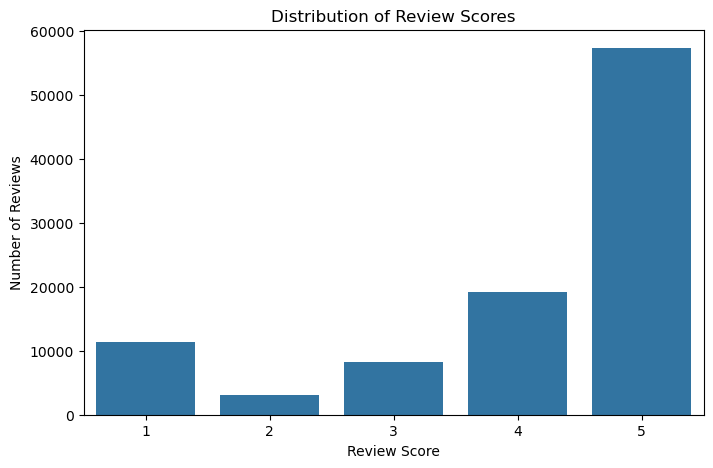

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=reviews,
    x="review_score"
)

plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.show()

### 2. Delivery Time Distribution

Delivery time is strongly right-skewed. Most orders are delivered within
approximately 5–20 days, while a relatively small number of orders take
substantially longer.

The mean delivery time (12.56 days) is higher than the median (10.22 days),
which is consistent with the presence of a long right tail.

The distribution indicates that delivery time is not normally distributed.

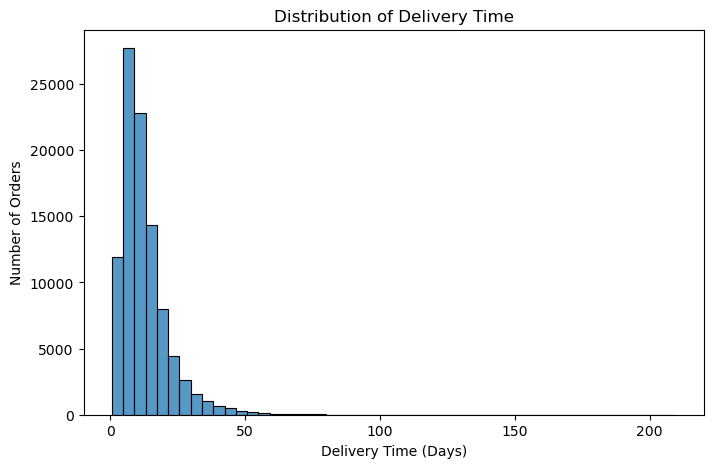

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=orders,
    x="delivery_time_days",
    bins=50
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.show()

## Correlation Analysis

### Whether longer delivery time associated with lower customer review scores?

In [18]:
reviews_per_order = (
    reviews
    .groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "mean")
    )
)

In [19]:
reviews_per_order.shape

(98673, 2)

In [20]:
stats_df = orders[
    [
        "order_id",
        "delivery_time_days",
        "delivery_delay_days"
    ]
].merge(
    reviews_per_order,
    on="order_id",
    how="inner"
)

In [21]:
stats_df.shape

(98673, 4)

In [22]:
stats_df.isna().sum()

order_id                  0
delivery_time_days     2843
delivery_delay_days    2843
review_score              0
dtype: int64

In [23]:
correlation = stats_df[
    ["delivery_time_days", "review_score"]
].corr(method="pearson")

correlation

,delivery_time_days,review_score
delivery_time_days,1.000000,-0.334302
review_score,-0.334302,1.000000


In [24]:
spearman_corr = stats_df[
    ["delivery_time_days", "review_score"]
].corr(method="spearman")

spearman_corr

,delivery_time_days,review_score
delivery_time_days,1.000000,-0.234849
review_score,-0.234849,1.000000


### Delivery Time and Review Score

Correlation analysis was performed to evaluate the association between
delivery time and customer review score.

Pearson correlation produced a coefficient of -0.334, indicating a
moderate negative linear association. Spearman rank correlation produced
a coefficient of -0.235, indicating a weaker but consistent negative
monotonic association.

Both methods show the same negative direction, suggesting that longer
delivery times tend to be associated with lower customer review scores.

The difference between the Pearson and Spearman coefficients indicates
that the relationship is not purely linear and may be influenced by the
right-skewed distribution and extreme values in delivery time.

Correlation indicates association and does not establish causation.

## Hypothesis Test 1

### Null hypothesis (H₀):
The mean review score is the same for on-time and delayed orders.

### Alternative hypothesis (H₁):
The mean review score differs between on-time and delayed orders.

In [32]:
stats_df["delivery_status"] = np.where(
    stats_df["delivery_delay_days"] > 0,
    "Delayed",
    "On-Time"
)

In [33]:
stats_df["delivery_status"].value_counts()

delivery_status
On-Time    91011
Delayed     7662
Name: count, dtype: int64

In [34]:
stats_df.groupby("delivery_status")["review_score"].agg(
    ["count", "mean", "std", "median"]
)

,count,mean,std,median
delivery_status,,,,
Delayed,7662,2.566562,1.657714,2.0
On-Time,91011,4.214778,1.234007,5.0


In [35]:
# Welch's t-test
from scipy.stats import ttest_ind

In [36]:
delayed_reviews = stats_df.loc[
    stats_df["delivery_status"] == "Delayed",
    "review_score"
]

on_time_reviews = stats_df.loc[
    stats_df["delivery_status"] == "On-Time",
    "review_score"
]

In [40]:
t_stat, p_value = ttest_ind(
    delayed_reviews,
    on_time_reviews,
    equal_var=False
)

t_stat, p_value

(-85.069617845055, 0.0)

## Cohen's d — effect size

### How large is the difference between the two groups relative to their variability?

In [38]:
n_delayed = delayed_reviews.count()
n_on_time = on_time_reviews.count()

mean_delayed = delayed_reviews.mean()
mean_on_time = on_time_reviews.mean()

std_delayed = delayed_reviews.std()
std_on_time = on_time_reviews.std()

pooled_std = np.sqrt(
    (
        (n_delayed - 1) * std_delayed**2
        + (n_on_time - 1) * std_on_time**2
    )
    /
    (n_delayed + n_on_time - 2)
)

cohens_d = (
    mean_delayed - mean_on_time
) / pooled_std

cohens_d

-1.295799789527247

### Delivery Status and Review Score

To evaluate whether customer satisfaction differs between delayed and
on-time orders, an independent two-sample Welch's t-test was conducted.

The mean review score was 2.57 for delayed orders compared with 4.21 for
on-time orders, representing a mean difference of approximately 1.65
review points.

The test produced a t-statistic of -85.07 with p < 0.001. Therefore, the
null hypothesis that the two groups have equal mean review scores was
rejected.

Cohen's d was -1.30, indicating a very large standardized effect. The
negative sign reflects the lower review scores observed among delayed
orders.

Overall, the analysis provides strong statistical evidence that delivery
status is associated with customer satisfaction, with delayed orders
receiving substantially lower review scores than on-time orders.

This analysis demonstrates association rather than causation.

## Hypothesis Test 2 — Delivery-Time Category vs Review Score

In [41]:
stats_df["delivery_time_category"] = pd.cut(
    stats_df["delivery_time_days"],
    bins=[0, 7, 14, 21, np.inf],
    labels=["0–7 Days", "8–14 Days", "15–21 Days", "22+ Days"],
    include_lowest=True
)

In [42]:
stats_df["delivery_time_category"].value_counts().sort_index()

delivery_time_category
0–7 Days      25933
8–14 Days     40000
15–21 Days    17582
22+ Days      12315
Name: count, dtype: int64

In [43]:
stats_df.groupby(
    "delivery_time_category",
    observed=True
)["review_score"].agg(
    ["count", "mean", "std", "median"]
)

,count,mean,std,median
delivery_time_category,,,,
0–7 Days,25933,4.418437,1.065530,5.0
8–14 Days,40000,4.312012,1.136606,5.0
15–21 Days,17582,4.139831,1.232580,5.0
22+ Days,12315,3.119881,1.664474,3.0


In [44]:
## Running ANOVA 
from scipy.stats import f_oneway

In [45]:
groups = [
    group["review_score"].dropna()
    for _, group in stats_df.groupby(
        "delivery_time_category",
        observed=True
    )
]

f_stat, p_value = f_oneway(*groups)

f_stat, p_value

(3597.2035407284893, 0.0)

In [48]:
# post-hoc Tukey HSD test

tukey_df = stats_df[
    ["delivery_time_category", "review_score"]
].dropna().copy()

tukey_df["delivery_time_category"] = (
    tukey_df["delivery_time_category"]
    .astype(str)
)

In [49]:
tukey_df.dtypes

delivery_time_category     object
review_score              float64
dtype: object

In [50]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_result = pairwise_tukeyhsd(
    endog=tukey_df["review_score"],
    groups=tukey_df["delivery_time_category"],
    alpha=0.05
)

print(tukey_result)

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1     group2   meandiff p-adj  lower   upper  reject
-----------------------------------------------------------
  0–7 Days 15–21 Days  -0.2786   0.0 -0.3092 -0.2481   True
  0–7 Days   22+ Days  -1.2986   0.0 -1.3328 -1.2643   True
  0–7 Days  8–14 Days  -0.1064   0.0 -0.1314 -0.0815   True
15–21 Days   22+ Days  -1.0199   0.0 -1.0567 -0.9832   True
15–21 Days  8–14 Days   0.1722   0.0  0.1439  0.2005   True
  22+ Days  8–14 Days   1.1921   0.0  1.1599  1.2244   True
-----------------------------------------------------------


## Statistical Conclusions

The statistical analysis provides consistent evidence of a strong
relationship between delivery performance and customer satisfaction.

Pearson and Spearman correlation both identified a negative association
between delivery time and review score (r = -0.334 and ρ = -0.235,
respectively), indicating that longer delivery times tend to be
associated with lower customer ratings.

A Welch's independent two-sample t-test found a statistically significant
difference in review scores between delayed and on-time orders
(t = -85.07, p < 0.001). Delayed orders had an average review score of
2.57 compared with 4.21 for on-time orders. Cohen's d = -1.30 indicates
a very large standardized effect.

A one-way ANOVA further demonstrated statistically significant
differences in review scores across delivery-time categories
(F = 3597.20, p < 0.001). Tukey HSD post-hoc testing showed that every
pair of delivery-time categories differed significantly from one another
(p < 0.001).

The results consistently indicate that longer and delayed deliveries
are associated with substantially lower customer satisfaction. In
particular, orders taking 22 or more days had an average review score of
3.12, compared with 4.42 for orders delivered within 0–7 days.

These findings demonstrate strong statistical association, but they do
not establish causation. Other factors may also influence customer
satisfaction.

## Business Implications

Delivery performance represents a critical customer-experience
lever. The substantial decline in review scores among delayed and
very slow orders suggests that reducing delivery delays and preventing
extreme delivery durations should be a priority for improving customer
satisfaction and supporting customer retention.

The 22+ day delivery segment is particularly important because it
combines a relatively large customer population with substantially
lower satisfaction than all faster delivery segments.

Business actions should therefore focus on identifying the operational
causes of extreme delivery times, improving seller and carrier
performance, and prioritizing interventions for orders at high risk of
significant delay.